In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.integrate as sp


# System

$$
\begin{align}
C\dot V_i =&\; -I_L - I_{Na} - I_K - I_T + I_{SM} \\
&\;+ \frac{\alpha_c}{N} \sum_{k=1}^N(V_k - V_i) + \sqrt{2D}\nu_i + u_i \\
\dot h_i =&\; \frac{h_{\infty} - h_i}{\tau_h} \\
\dot r_i =&\; \frac{r_{\infty}-r_i}{\tau_r}\hspace{0.5cm}1,...N
\end{align}
$$
With system observed by
$$
y(t) = \frac{1}{N}\sum_{j=1}^N V_i(t)
$$

* State Variables
    * $V_i$: is the transmembrane voltage of neuron $i$
    * $h_i$ and $r_i$: are corredponding gating variables
* Coefficient Variables given as
    * $C = 1\frac{\mu F}{cm^2}$
    * $I_L(V_i) = $
    * $I_{Na}(V_i,h_i) = $
    * $I_k(V_i,h_i) = $
    * $I_T(V_i,r_i) = $
    * $I_{SM}=5\frac{\mu A}{cm^2}$: is a baseline current so that each neuron fires periodically in the absence of external input, noise, and coupling
    * $\alpha_c = 0.05\frac{mS}{cm^2}$: magnitude of the electrotonic coupling strength
    * $\sqrt{2D}\nu_i(t) $: independent and identically distributed zero-mean white noise process with intensity $D =0.1$
    * $\nu_i(t) = $
    * $u_i(t) $: direct current input applied to neuron i
    * $h_{\infty}(V_i)= $
    * $\tau_h(V_i) = $
    * $r_{\infty}(V_i)=$
    * $\tau_r(V_i) =$
* Simulation Variables
    * $N=10$: neurons
    * $\theta_0 \equiv -40mV$: on the upstroke of an action potential


# Method 1

In [ ]:
def hdot(step_m):
    cV_m = step_m[:,0]
    h_m = step_m[:,1]
    # r_m = step_m[:,2]

    def h_free(V):
        return 1/(1+np.exp((V + 41)/4))
    def tau_h(V):
        ah = 0.128*np.exp(-(V+46)/18)
        bh = 4/(1+np.exp(-(V+23)/5))
        return 1/(ah + bh)

    dh = (h_free(cV_m) - h_m)/tau_h(cV_m)
    return  dh

In [ ]:
def rdot(step_m):
    cV_m = step_m[:,0]
    # h_m = step_m[:,1]
    r_m = step_m[:,2]

    def r_free(V):
        return 1/(1+np.exp((V+84)/4))
    def tau_r(V):
        return 28 + np.exp(-(V+25)/10.5)

    dr = (r_free(cV_m)-r_m)/tau_r(cV_m)

    return  dr

In [ ]:
def cVdot(step_m,dt,m):
    cV_m = step_m[:,0]
    h_m = step_m[:,1]
    r_m = step_m[:,2]

    minf = 1/(1+np.exp(-(cV_m+37)/7))
    pinf = 1/(1+np.exp(-(cV_m+60)/6.2))

    D = 0.01
    alp = 0.05
    Ism = 5



    gL = 0.5
    EL = -70
    IL = gL*(cV_m - EL)

    gNa = 3
    ENa = 50
    INa = gNa*minf**3*h_m*(cV_m - ENa)

    gK = 5
    EK = -90
    IK = gK*(0.75*(1-h_m))**4*(cV_m - EK)

    gT = 5
    ET = 0
    IT = gT*pinf**2*r_m*(cV_m - ET)


    N = cV_m.size

    cupling = np.zeros(cV_m.shape)

    for i in range (N):
        Vi = cV_m[i]
        for k in range(N):
            Vk = cV_m[k]
            cupling[i] += Vk - Vi

        cupling[i] = alp*cupling[i]/N


    def pulse(dt,m,N):
        u = np.zeros(N)

        if dt*m <=2e-5:
            for i in range(int(N/2)):
                u[i] = 25

        return u

    def noise(dt,m,N):
        return np.zeros(N)

    dcV = -IL - INa - IK - IT + Ism  + cupling + np.sqrt(2*D)*noise(dt,m,N) + pulse(dt,m,N)

    return  dcV

In [ ]:
def sim(Neur0,dt,steps):
    data = np.empty((Neur0.shape[0],steps,Neur0.shape[1]))
    data[:,0] = Neur0



    for m in range(steps-1):
        step_m = data[:,m].copy()
        data[:,m+1,0] = dt*cVdot(step_m,dt,m) + step_m[:,0]
        data[:,m+1,1] = dt*hdot(step_m) + step_m[:,1]
        data[:,m+1,2] = dt*rdot(step_m) + step_m[:,2]


    Y = np.mean(data[:,:,0],axis=0)


    return Y, data[:,-1,:]

In [ ]:
# def observ(V,axis=1):
#     return np.mean(V,axis=1)

In [ ]:
# def pulse(dt,m,N):
#     u = np.zeros(N)

#     if dt*m <=2e-5:
#         for i in range(int(N/2)):
#             u[i] = 250

#     return u

# Method 2

In [2]:
def hdot(step_m,t):
    cV_m = step_m[:,0]
    h_m = step_m[:,1]
    # r_m = step_m[:,2]

    def h_free(V):
        return 1/(1+np.exp((V + 41)/4))
    def tau_h(V):
        ah = 0.128*np.exp(-(V+46)/18)
        bh = 4/(1+np.exp(-(V+23)/5))
        return 1/(ah + bh)

    dh = (h_free(cV_m) - h_m)/tau_h(cV_m)
    return  dh

In [3]:
def rdot(step_m,t):
    cV_m = step_m[:,0]
    # h_m = step_m[:,1]
    r_m = step_m[:,2]

    def r_free(V):
        return 1/(1+np.exp((V+84)/4))
    def tau_r(V):
        return 28 + np.exp(-(V+25)/10.5)

    dr = (r_free(cV_m)-r_m)/tau_r(cV_m)

    return  dr

In [4]:
def cVdot(step_m,t):
    cV_m = step_m[:,0]
    h_m = step_m[:,1]
    r_m = step_m[:,2]

    minf = 1/(1+np.exp(-(cV_m+37)/7))
    pinf = 1/(1+np.exp(-(cV_m+60)/6.2))

    D = 0.01
    alp = 0.05
    Ism = 5



    gL = 0.5
    EL = -70
    IL = gL*(cV_m - EL)

    gNa = 3
    ENa = 50
    INa = gNa*minf**3*h_m*(cV_m - ENa)

    gK = 5
    EK = -90
    IK = gK*(0.75*(1-h_m))**4*(cV_m - EK)

    gT = 5
    ET = 0
    IT = gT*pinf**2*r_m*(cV_m - ET)


    N = cV_m.size

    cupling = np.zeros(cV_m.shape)

    for i in range (N):
        Vi = cV_m[i]
        for k in range(N):
            Vk = cV_m[k]
            cupling[i] += Vk - Vi

        cupling[i] = alp*cupling[i]/N


    def pulse(t,N):
        u = np.zeros(N)

        if t <=2e-5:
            for i in range(int(N/2)):
                u[i] = 5

        return u

    def noise(t,N):
        return np.zeros(N)

    dcV = -IL - INa - IK - IT + Ism  + cupling + np.sqrt(2*D)*noise(t,N) + pulse(t,N)

    return  dcV

In [5]:
def Sys(X,t):
    X = np.reshape(X,(10,3))
    step = np.empty(X.shape)

    step[:,0] = cVdot(X,t)
    step[:,1] = hdot(X,t)
    step[:,2] = rdot(X,t)

    step = np.reshape(step,30)
    return step

# Simulation

## Sim Method 1

In [ ]:
# def pulse(dt,m,N):
#         u = np.zeros(N)

#         if dt*m <=2e-5:
#             for i in range(int(N/2)):
#                 u[i] = 250

#         return u
# for i in range(numSteps):
#      plt.scatter(t[i],pulse(stepSize,i,10)[0])

In [ ]:
stepSize = 1e-6
numSteps = 200000


t = np.linspace(0,stepSize*numSteps,numSteps)

In [ ]:
# IC = -40e-3*np.ones((10,3))
# IC = pd.read_csv('fixP.csv').to_numpy()
IC

array([[-6.27387097e+01,  9.94785876e-01, -2.79177978e-02],
       [-6.27387097e+01,  9.94785876e-01, -2.79177978e-02],
       [-6.27387097e+01,  9.94785876e-01, -2.79177978e-02],
       [-6.27387097e+01,  9.94785876e-01, -2.79177978e-02],
       [-6.27387097e+01,  9.94785876e-01, -2.79177978e-02],
       [-6.27387110e+01,  9.94785894e-01, -2.79178185e-02],
       [-6.27387110e+01,  9.94785894e-01, -2.79178185e-02],
       [-6.27387110e+01,  9.94785894e-01, -2.79178185e-02],
       [-6.27387110e+01,  9.94785894e-01, -2.79178185e-02],
       [-6.27387110e+01,  9.94785894e-01, -2.79178185e-02]])

In [ ]:
raw, LC = sim(IC,stepSize,numSteps)

In [ ]:
stepSize*numSteps

0.19999999999999998

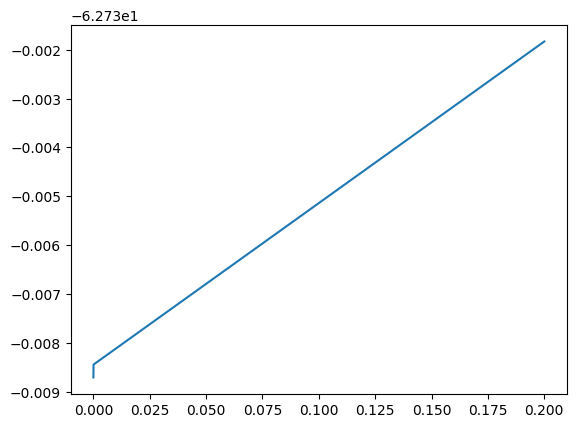

In [ ]:
plt.plot(t,raw)

In [ ]:
LC

array([[-6.27316066e+01,  9.94840513e-01, -2.78160339e-02],
       [-6.27316066e+01,  9.94840513e-01, -2.78160339e-02],
       [-6.27316066e+01,  9.94840513e-01, -2.78160339e-02],
       [-6.27316066e+01,  9.94840513e-01, -2.78160339e-02],
       [-6.27316066e+01,  9.94840513e-01, -2.78160339e-02],
       [-6.27320562e+01,  9.94840564e-01, -2.78160554e-02],
       [-6.27320562e+01,  9.94840564e-01, -2.78160554e-02],
       [-6.27320562e+01,  9.94840564e-01, -2.78160554e-02],
       [-6.27320562e+01,  9.94840564e-01, -2.78160554e-02],
       [-6.27320562e+01,  9.94840564e-01, -2.78160554e-02]])

In [ ]:
# fixP_list = {'V':LC[:,0],
#              'h':LC[:,1],
#              'r':LC[:,2]}


# fixP_df = pd.DataFrame(fixP_list)
# fixP_df.to_csv('fixP.csv',index=False)

## Sim Meth 2

In [6]:
stepSize = 1e-6
numSteps = 200000


# t = np.linspace(0,stepSize*numSteps,numSteps)
t = np.arange(0,80,1e-5)

In [7]:
IC = np.zeros((10,3))
IC[:,0] = -40e-3*np.ones(10)


# IC = pd.read_csv('fixP.csv').to_numpy()

# IC = np.ones(10)*-40e-3

IC = np.reshape(IC,30)

In [8]:
data = sp.odeint(Sys,IC,t)
data = np.reshape(data,(10,t.size,3))

In [9]:
y = np.mean(data[:,:,0],axis=0)

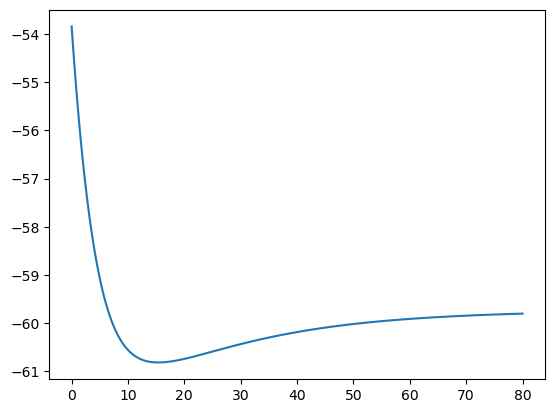

In [10]:
plt.plot(t,y)

In [11]:
IC2 = data[:,-1,:]

In [188]:
stepSize = 1e-9
numSteps = 800


t = np.linspace(0,2e-3,100)
# t = np.arange(0,2e-4,1e-5)

In [189]:
t.size

100

In [190]:
IC2 = np.reshape(IC2,30)
data2 = sp.odeint(Sys,IC2,t)
data2 = np.reshape(data2,(10,t.size,3))
y2 = np.mean(data2[:,:,0],axis=0)


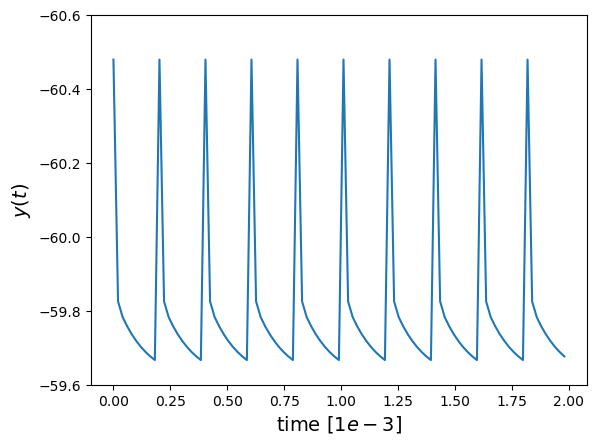

In [192]:
tmin = 0
tmax = -1

plt.plot(t[tmin:tmax]/1e-3,y2[tmin:tmax])

plt.ylabel(r'$y(t)$',fontsize=14)
plt.xlabel(r'time $[1e-3]$',fontsize=14)
plt.ylim([-59.6,-60.6])

# plt.savefig('./exam2_plts/myCode_outPut.png', transparent=True, dpi=400, bbox_inches='tight')

plt.show()

# Dimension testing

In [ ]:
IC = np.zeros((10,3))
IC

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
Test = np.empty((IC.shape[0],10,IC.shape[1]))
Test

array([[[ 2.47032823e-323,  6.95242400e-310,              nan],
        [ 1.44208991e-311,  1.44233796e-311,  0.00000000e+000],
        [             nan,  0.00000000e+000,  1.44233791e-311],
        [             nan,  1.44208991e-311,  1.44233796e-311],
        [ 1.90979621e-313,  0.00000000e+000,  0.00000000e+000],
        [ 1.44233791e-311,              nan,  1.44208991e-311],
        [ 1.44233796e-311,  1.48539705e-313,  2.76676762e-322],
        [ 0.00000000e+000,  4.94065646e-324,  3.33568614e+151],
        [             nan,  1.44208991e-311,  1.44233796e-311],
        [ 4.24399158e-314,  5.53353523e-322,  4.94065646e-324]],

       [[ 1.44233791e-311,  4.47593816e-091,  1.44208991e-311],
        [ 1.44233796e-311,  1.90979621e-313,  8.69555537e-322],
        [ 4.94065646e-324,  2.59459196e+161,              nan],
        [ 1.44208991e-311,  1.44233796e-311,  6.36598737e-314],
        [ 1.14623230e-321,  1.13556095e-153,  1.44233791e-311],
        [ 3.45035691e+175,  1.44208991

In [ ]:
step_test = Test[:,0].copy()
step_test

array([[2.47032823e-323, 6.95242400e-310,             nan],
       [1.44233791e-311, 4.47593816e-091, 1.44208991e-311],
       [            nan, 1.44208991e-311, 1.44233796e-311],
       [5.26750679e+170, 2.12199579e-314,             nan],
       [4.18967668e-321, 1.44233796e-311, 1.54380364e+256],
       [1.44233796e-311, 2.33419537e-313, 5.45448473e-321],
       [            nan, 1.44208991e-311, 1.44233796e-311],
       [4.94065646e-323, 1.44233791e-311,             nan],
       [8.93270688e-321, 1.44233796e-311, 5.92878775e-323],
       [1.44233796e-311, 1.27319747e-313, 1.01975149e-320]])

In [ ]:
cV_m_test = step_test[:,0]
cV_m_test

array([2.47032823e-323, 1.44233791e-311,             nan, 5.26750679e+170,
       4.18967668e-321, 1.44233796e-311,             nan, 4.94065646e-323,
       8.93270688e-321, 1.44233796e-311])

In [ ]:
cV_m_test.shape

(10,)